Model Evaluation:
Mean Squared Error (MSE): 1754318687330.663
Root Mean Squared Error (RMSE): 1324506.9600914384
R² Score: 0.6529242642153186

Model Coefficients:
area: 235.97
bedrooms: 76778.70
bathrooms: 1094444.79
stories: 407476.59
parking: 224841.91
mainroad_yes: 367919.95
guestroom_yes: 231610.04
basement_yes: 390251.18
hotwaterheating_yes: 684649.89
airconditioning_yes: 791426.74
prefarea_yes: 629890.57
furnishingstatus_semi-furnished: -126881.82
furnishingstatus_unfurnished: -413645.06
Intercept: 260032.35760740843


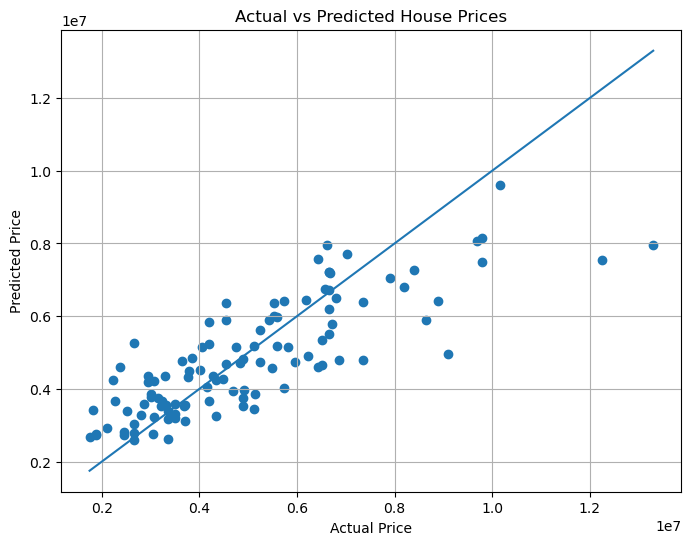

In [6]:
# step1:we import the libraries required.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
# step2:loading the dataset
ds=pd.read_csv("housing.csv")
# step3:converting columns to numeric
CategoricalCols=['mainroad', 'guestroom', 'basement',
                 'hotwaterheating','airconditioning',
                 'prefarea','furnishingstatus']
ds=pd.get_dummies(ds,columns=CategoricalCols,drop_first=True)
# step4:select features and the target
X=ds.drop('price',axis=1)
Y=ds['price']
# step5:split into training and test sets
X_train, X_test, Y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
# step6:train model
model=LinearRegression()
model.fit(X_train,Y_train)
# Step 7: Make predictions
y_pred = model.predict(X_test)
# Step 8: Evaluate the model
print("Model Evaluation:")
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))
# Step9:Model Coefficients
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
print("Intercept:", model.intercept_)
# Step10: Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()
